In [1]:
import napari 
from util.util_jk import loadnii
import numpy as np
import networkx as nx
from util.util_jk import loadmat

recon_hf = r'c:\Users\go34nuy\data\test\processed\recon\R_CF_ER01_P1HF.mat'
recon_lf = r'c:\Users\go34nuy\data\test\processed\recon\R_CF_ER01_P1LF.mat'
layseg_path = r"C:\Users\go34nuy\data\test\processed\epidermis_segmentation\R_CF_ER01_P1.nii.gz"
vesselseg_path = r"C:\Users\go34nuy\data\test\processed\vessel_segmentation\R_CF_ER01_P1.nii.gz"
graph_path = r"C:\Users\go34nuy\data\test\processed\vessel_segmentation\vesselvio\Graphs\R_CF_ER01_P1.graphml"

def surfaceToMask(surface:np.ndarray, Nz:int, width:int=1):
    Nx, Ny = surface.shape
    surface = np.clip(surface, 0, Nz-1)
    mask = np.zeros(shape=(Nx, Ny, Nz), dtype=np.int8)
    for i in range(Nx):
        for j in range(Ny):
            mask[i, j, int(surface[i, j]):int(surface[i, j] + width)]=1
    return mask
FLATTEN = True

def flatten(vol, surface):
    Nx,Ny,Nz = vol.shape
    heighest = np.min(surface)
    flat_vol = np.empty_like(vol, dtype=np.double)
    x, y = np.arange(0, Nx), np.arange(0, Ny)
    xg, yg = np.meshgrid(x, y, indexing='ij')
    for it, (i, j) in enumerate(zip(xg.ravel(), yg.ravel())):
        diff = int(surface[i,j] - heighest)
        flat_vol[i,j, :Nz-diff] = vol[i,j, diff:]
    return flat_vol


def flatten_to_depth(vol, surface, depth):
    Nx, Ny, Nz = vol.shape
    flat_vol = np.zeros_like(vol, dtype=np.double)
    for i in range(Nx):
        for j in range(Ny):
            shift = int(depth - surface[i, j])
            z_start = max(0, shift)
            z_end = min(Nz, Nz + shift) if shift < 0 else Nz - shift

            src_z = slice(max(0, -shift), max(0, -shift) + z_end - z_start)
            dst_z = slice(z_start, z_start + z_end - z_start)

            flat_vol[i, j, dst_z] = vol[i, j, src_z]
    return flat_vol

def flatten_coords(coords, surface, depth):
    coords = np.asarray(coords)
    yx = coords[:,[0,1]].round().astype(int)
    shift = depth - surface[yx[:,0], yx[:,1]]
    coords[:,2] += shift
    return coords



In [2]:

fr = loadmat(recon_lf)
R_lf = fr["R"].T
R_lf = np.clip(R_lf, 0, np.max(R_lf))

fr = loadmat(recon_hf)
R_hf = fr["R"].T
R_hf = np.clip(R_hf, 0, np.max(R_hf))

layseg = loadnii(layseg_path)
layseg = np.array(layseg, dtype=np.float32)
layseg = layseg.transpose(1, 2, 0)

vesseg = loadnii(vesselseg_path)
vesseg = np.array(vesseg, dtype=np.float32)
vesseg = vesseg.transpose(1, 2, 0)

G = nx.read_graphml(graph_path)
nodes = []
for n, d in G.nodes(data=True):
    x, y, z = float(d['X']), float(d['Y']), float(d['Z'])
    nodes.append([y, z, x])   # napari expects (z,y,x)

edges = []
for u, v, d in G.edges(data=True):
    ux, uy, uz = float(G.nodes[u]['X']), float(G.nodes[u]['Y']), float(G.nodes[u]['Z'])
    vx, vy, vz = float(G.nodes[v]['X']), float(G.nodes[v]['Y']), float(G.nodes[v]['Z'])
    edges.append([[uy, uz, ux], [vy, vz, vx]])

junction_surface = layseg.shape[2] - 1 - np.argmax(np.flip(layseg, axis=2), axis=2)

ds = int(fr["rP"]["ds"])
dz = int(fr["rP"]["dz"])
scale = (ds,ds,2*dz)

# vp_depth = 40
layer_vescrop = surfaceToMask(junction_surface, R_lf.shape[2])


nodes_flat = flatten_coords(nodes, junction_surface, 0)
z_vals = nodes_flat[:, 2]

counts, bins = np.histogram(z_vals, bins=30)
threshold = 0.3 * counts.max()
z_thr = bins[np.where(counts >= threshold)[0][-1]]
vp_depth = np.max(abs(z_vals))-abs(z_thr)

layer_vescrop = surfaceToMask(junction_surface, R_lf.shape[2])
print(vp_depth)



if FLATTEN:
    R_hf_flat = flatten(R_hf, junction_surface)
    R_lf_flat = flatten(R_lf, junction_surface)
    layseg_flat = flatten(layseg, junction_surface)
    junction_surface_flat = layseg_flat.shape[2] - 1 - np.argmax(np.flip(layseg_flat, axis=2), axis=2)
    vesseg_flat = flatten(vesseg, junction_surface)
    nodes_flat = flatten_coords(nodes, junction_surface, 0)
    edges_flat = [flatten_coords(e, junction_surface, 0) for e in edges]




36.53333333333333


In [3]:
layseg.shape

(160, 328, 1176)

In [75]:
viewer = napari.Viewer( ndisplay=3)
viewer.add_image(R_hf, blending='additive', colormap='green', scale=scale, name = 'HF', rotate=-90)
viewer.add_image(R_lf, blending='additive', colormap='red', scale=scale, name = 'LF', rotate=-90)
viewer.add_image(layseg, opacity=0.5, blending='additive', colormap='grey', scale=scale, name='layseg', visible=False, rotate=-90)
viewer.add_image(vesseg, opacity=0.5, blending='additive', colormap='grey', scale=scale, name='vesseg', visible=True, rotate=-90, translate=(0,(scale[2]*np.min(junction_surface)),0))

viewer.add_image(layer_vescrop, opacity=1, blending='additive', colormap='grey', scale=scale, name='UpperLower cut', visible=True, rotate=-90, translate=(0,np.min(junction_surface)+vp_depth,0))
viewer.add_points(nodes, size=5, face_color="red", scale=scale, name="nodes", rotate=-90, translate=(0,scale[2]*np.min(junction_surface),0))
viewer.add_shapes(edges, shape_type="path", edge_color="blue", scale=scale, name="edges", rotate=-90, translate=(0,scale[2]*np.min(junction_surface), 0))

napari.run()


c:\Users\go34nuy\AppData\Local\anaconda3\envs\h5pyEnv\lib\site-packages\vispy\visuals\tube.py:136: RuntimeWarning: invalid value encountered in divide
  tangents /= mags[:, np.newaxis]


array([  13.,    0., -204.])

In [85]:
z_thr

-170.46666666666667

TypeError: only integer scalar arrays can be converted to a scalar index

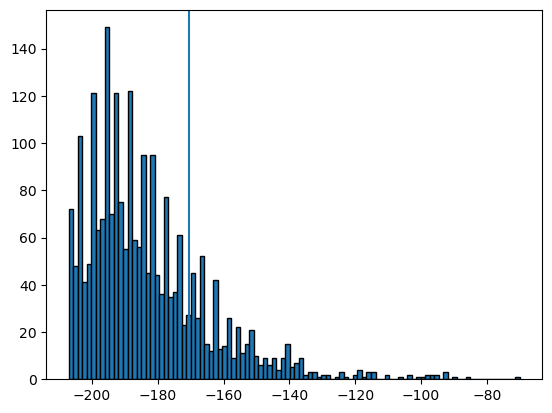

In [ ]:
# j_patches = 3
# k_patches = 4
# x_diff = (nodes_flat[:, 0].min(), nodes_flat[:, 0].max())
# y_diff = (nodes_flat[:, 1].min(), nodes_flat[:, 1].max())
# z_diff = (nodes_flat[:, 2].min(), nodes_flat[:, 2].max())

# size_patches = ((x_diff[1] - x_diff[0]) / j_patches, (y_diff[1] - y_diff[0]) / k_patches)

# print(x_diff, y_diff,z_diff, size_patches)
# for j in range(j_patches):
#     for k in range(k_patches):
#         idxs = np.all([nodes_flat[:, 0]>(j*size_patches[0]), nodes_flat[:, 0]<((j+1)*size_patches[0]), nodes_flat[:, 1]>(k*size_patches[1]), nodes_flat[:, 1]<((k+1)*size_patches[1])], axis=0)

#         z_vals = nodes_flat[idxs, 2]

#         counts, bins = np.histogram(z_vals, bins=10)
#         import matplotlib.pyplot as plt
#         plt.figure()
#         plt.bar(bins[:-1], counts, width=np.diff(bins), edgecolor='k', align='edge')





z_vals = nodes_flat[:, 2]


counts, bins = np.histogram(z_vals, bins=100)

import matplotlib.pyplot as plt
plt.figure()
plt.bar(bins[:-1], counts, width=np.diff(bins), edgecolor='k', align='edge')

threshold = 0.3 * counts.max()
z_thr = bins[np.where(counts >= threshold)[0][-1]]
plt.axvline(-170.46)
mask_low  = z_vals <= z_thr  
mask_high = z_vals >  z_thr

nodes_low  = nodes_flat[mask_low] 
nodes_high = nodes_flat[mask_high]

In [8]:
viewer = napari.Viewer(ndisplay=3)

viewer.add_points(nodes_flat, size=5, face_color="red", scale=scale, name="nodes", rotate=-90, translate=(0,scale[2]*np.min(junction_surface),0))
viewer.add_shapes(edges_flat, shape_type="path", edge_color="blue", scale=scale, name="edges", rotate=-90, translate=(0,scale[2]*np.min(junction_surface), 0))
viewer.add_points(nodes_high, size=5, face_color="red", scale=scale, name="nodes_high", rotate=-90, translate=(0,scale[2]*np.min(junction_surface),0))
viewer.add_points(nodes_low, size=5, face_color="red", scale=scale, name="nodes_low", rotate=-90, translate=(0,scale[2]*np.min(junction_surface),0))
# viewer.add_shapes(edges_up, shape_type="path", edge_color="blue", scale=scale, name="edges", rotate=-90, translate=(0,scale[2]*np.min(junction_surface), 0))
# viewer.add_points(nodes, size=5, face_color="red", scale=scale, name="nodes", rotate=-90, translate=(0,scale[2]*np.min(junction_surface),0))
# viewer.add_shapes(edges, shape_type="path", edge_color="blue", scale=scale, name="edges", rotate=-90, translate=(0,scale[2]*np.min(junction_surface), 0))

napari.run()

c:\Users\go34nuy\AppData\Local\anaconda3\envs\h5pyEnv\lib\site-packages\vispy\visuals\tube.py:136: RuntimeWarning: invalid value encountered in divide
  tangents /= mags[:, np.newaxis]


<BarContainer object of 30 artists>

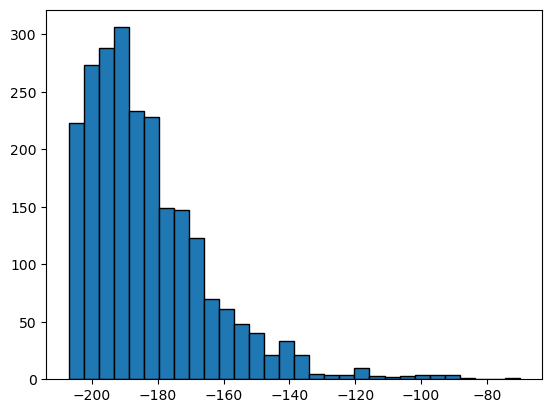

In [66]:
import matplotlib.pyplot as plt

plt.bar(bins[:-1], counts, width=np.diff(bins), edgecolor='k', align='edge')

In [ ]:
show 10 images, including legs, define good position
determine good percentage
validate against other 10